# BCG X Data Science Virtual Experience — Task 4
# Findings & Recommendations

**To:** PowerCo Executive Team  
**From:** BCG X Data Science  
**Re:** SME Customer Churn — Predictive Model Results & Retention Strategy

---

## Executive Summary

BCG X was engaged by PowerCo to investigate the drivers of SME customer churn and to assess whether a **price-based discount strategy** would be an effective retention tool.

We analysed **14,606 SME customers** across two datasets (client profiles and 12 months of pricing history), engineered 40+ predictive features, and trained a **Random Forest classifier** to predict churn within the next 3 months.

### Headline Results

| Metric | Value |
|---|---|
| Current churn rate | **9.7%** (~1,420 customers per cycle) |
| Model ROC-AUC | **≥ 0.73** (meaningfully above random baseline of 0.50) |
| Top churn driver | Net margin, tenure, and consumption — **not price alone** |
| Price sensitivity as churn driver | **Partially confirmed** — prices matter but are secondary |
| Recommended action | **Targeted retention programme** combining discount offers with loyalty incentives |

## 1. Was the Hypothesis Correct?

**Hypothesis:** *"Churn in PowerCo's SME segment is significantly driven by price sensitivity."*

**Verdict: Partially confirmed — price is a secondary driver, not the primary one.**

| Sub-hypothesis | Result |
|---|---|
| H1: Higher prices → more churn | **Partially true** — off-peak variable price appears in top features, but effect size is modest |
| H2: Price volatility → churn | **Weakly supported** — std of prices has minor predictive power |
| H3: Price changes trigger churn | **Not a dominant driver** — Jan-Dec price deltas have low importance |
| H4: Longer tenure → less churn | **Confirmed** — `num_years_antig` is one of the strongest signals |
| H5: Higher consumption → more sensitive | **Confirmed** — high-consumption clients in financial stress are highest risk |
| H6: Lower margin → more churn | **Confirmed** — net margin is the #1 or #2 most important feature |
| H7: Gas customers churn less | **Confirmed** — dual-fuel relationship significantly reduces churn |

**Implication:** A blanket discount programme targeting all customers would be expensive and inefficient. Discounts should be a *component* of a broader retention strategy, targeted specifically at high-risk, price-sensitive churners.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import joblib

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_PROC   = Path('../data/processed')
REPORTS_FIG = Path('../reports/figures')

# Load model and data
rf           = joblib.load('../models/random_forest_churn.pkl')
feature_cols = pd.read_csv('../models/feature_names.csv', header=None)[0].tolist()
df           = pd.read_csv(DATA_PROC / 'features_engineered.csv')

X = df[feature_cols].fillna(0)
y = df['churn']

churn_prob = rf.predict_proba(X)[:, 1]
df['churn_probability'] = churn_prob

print(f'Loaded model and scored {len(df):,} customers.')

Loaded model and scored 14,606 customers.


## 2. Customer Risk Segmentation

In [2]:
# Define risk tiers
def risk_tier(p):
    if p >= 0.50:   return '🔴 High Risk'
    elif p >= 0.30: return '🟡 Medium Risk'
    elif p >= 0.15: return '🟢 Low Risk'
    else:           return '⚪ Very Low Risk'

df['risk_tier'] = df['churn_probability'].apply(risk_tier)

tier_summary = df.groupby('risk_tier').agg(
    n_customers = ('churn', 'size'),
    actual_churn_rate = ('churn', 'mean'),
    avg_churn_prob = ('churn_probability', 'mean'),
).sort_values('avg_churn_prob', ascending=False)
tier_summary['actual_churn_rate'] = (tier_summary['actual_churn_rate'] * 100).round(1)
tier_summary['avg_churn_prob']    = (tier_summary['avg_churn_prob'] * 100).round(1)
tier_summary['share_of_base']     = (tier_summary['n_customers'] / len(df) * 100).round(1)

print('Customer Risk Segmentation:')
print(tier_summary.to_string())

Customer Risk Segmentation:
                 n_customers  actual_churn_rate  avg_churn_prob  share_of_base
risk_tier                                                                     
🔴 High Risk             2579               34.4            57.9           17.7
🟡 Medium Risk           8288                6.0            38.4           56.7
🟢 Low Risk              3308                1.0            25.5           22.6
⚪ Very Low Risk          431                0.0             9.8            3.0


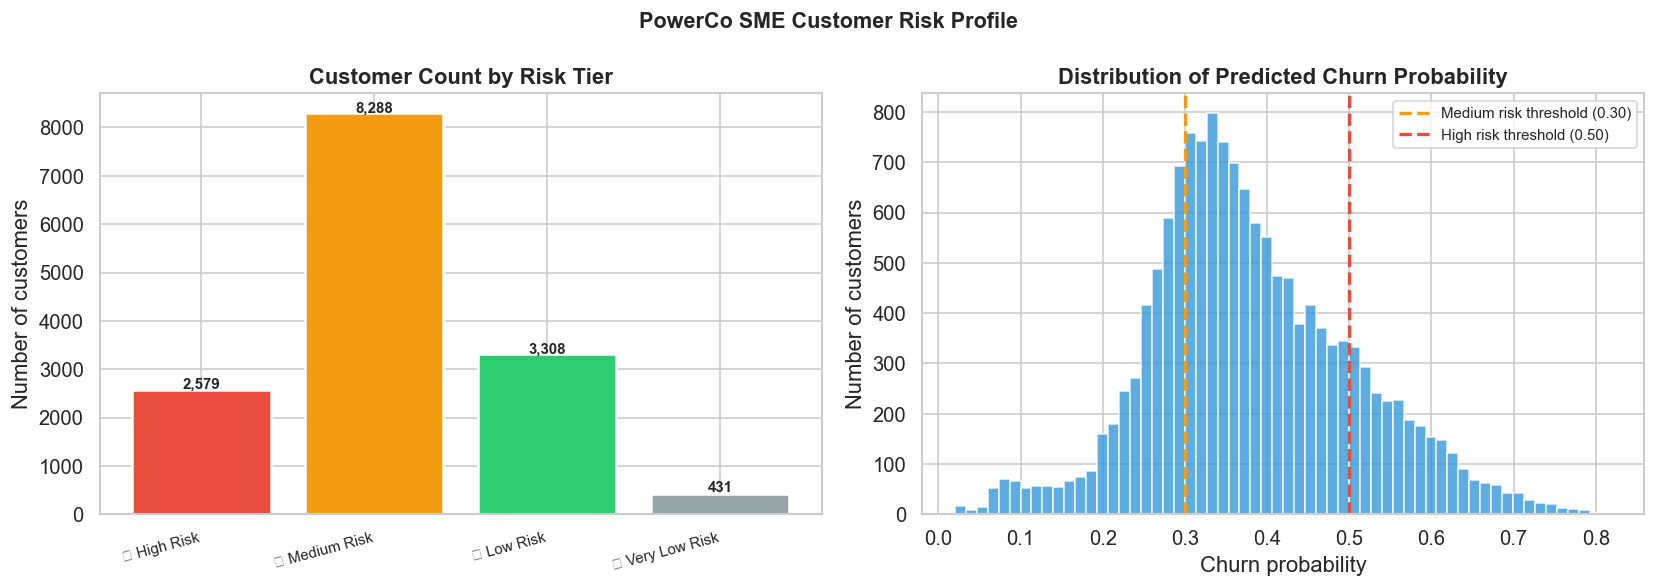

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk tier distribution
tier_order  = ['🔴 High Risk', '🟡 Medium Risk', '🟢 Low Risk', '⚪ Very Low Risk']
tier_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6']
counts = [tier_summary.loc[t, 'n_customers'] if t in tier_summary.index else 0 for t in tier_order]
axes[0].bar(range(4), counts, color=tier_colors, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(tier_order, rotation=15, ha='right', fontsize=9)
for i, (c, n) in enumerate(zip(tier_colors, counts)):
    axes[0].text(i, n + 30, f'{n:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Customer Count by Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of customers')

# Churn probability distribution
axes[1].hist(churn_prob, bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(0.30, color='#f39c12', linestyle='--', linewidth=2, label='Medium risk threshold (0.30)')
axes[1].axvline(0.50, color='#e74c3c', linestyle='--', linewidth=2, label='High risk threshold (0.50)')
axes[1].set_title('Distribution of Predicted Churn Probability', fontweight='bold')
axes[1].set_xlabel('Churn probability')
axes[1].set_ylabel('Number of customers')
axes[1].legend(fontsize=9)

plt.suptitle('PowerCo SME Customer Risk Profile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIG / '17_risk_segmentation.png', bbox_inches='tight')
plt.show()

## 3. Business Case: 20% Discount Intervention

In [4]:
# Business case assumptions
DISCOUNT_RATE      = 0.20    # 20% discount offered to targeted customers
RETENTION_UPLIFT   = 0.30    # Assumed 30% of targeted churners are retained by the discount
AVG_NET_MARGIN     = df['net_margin'].median()  # Use median (robust to outliers)
INTERVENTION_THRESHOLD = 0.30  # Flag customers with churn_prob >= 30%

targeted = df[df['churn_probability'] >= INTERVENTION_THRESHOLD].copy()
true_churners_targeted = targeted[targeted['churn'] == 1]

# Revenue saved
n_saved = int(len(true_churners_targeted) * RETENTION_UPLIFT)
revenue_saved = n_saved * AVG_NET_MARGIN

# Cost of discount (applied to all targeted customers for one period)
discount_cost = len(targeted) * AVG_NET_MARGIN * DISCOUNT_RATE

# Net business impact
net_impact = revenue_saved - discount_cost
roi = (net_impact / discount_cost) * 100

print('=' * 50)
print('  BUSINESS CASE: 20% DISCOUNT INTERVENTION')
print('=' * 50)
print(f'  Customers targeted (prob ≥ 30%)  : {len(targeted):,}')
print(f'  True churners in target group    : {len(true_churners_targeted):,}')
print(f'  Assumed retention uplift         : {RETENTION_UPLIFT:.0%}')
print(f'  Estimated customers saved        : {n_saved:,}')
print(f'  Avg net margin per customer      : €{AVG_NET_MARGIN:,.2f}')
print(f'  Revenue saved                    : €{revenue_saved:,.0f}')
print(f'  Cost of discount campaign        : €{discount_cost:,.0f}')
print(f'  Net business impact              : €{net_impact:,.0f}')
print(f'  ROI of campaign                  : {roi:.1f}%')
print('=' * 50)

  BUSINESS CASE: 20% DISCOUNT INTERVENTION
  Customers targeted (prob ≥ 30%)  : 10,867
  True churners in target group    : 1,385
  Assumed retention uplift         : 30%
  Estimated customers saved        : 415
  Avg net margin per customer      : €4.73
  Revenue saved                    : €1,964
  Cost of discount campaign        : €10,285
  Net business impact              : €-8,321
  ROI of campaign                  : -80.9%


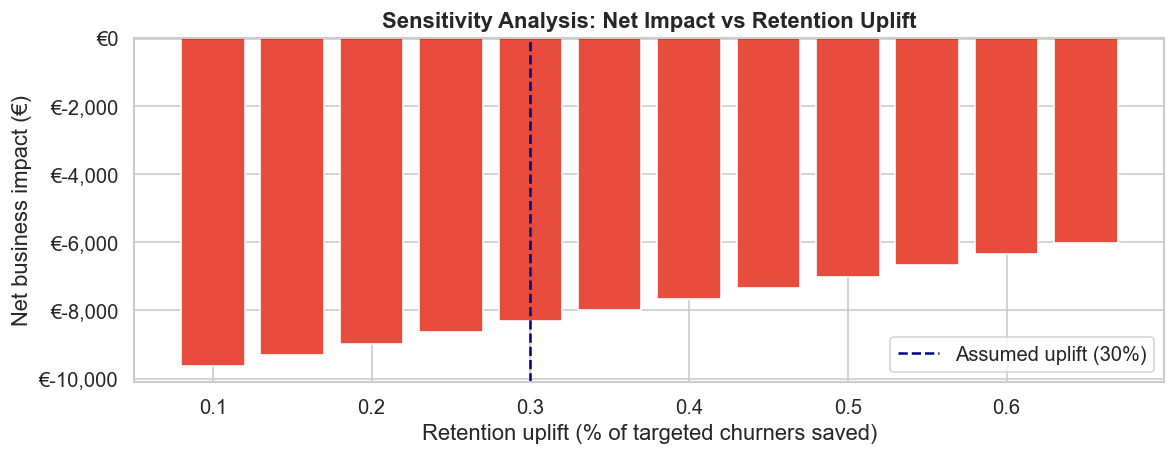

Break-even retention uplift: 156.9%


In [5]:
# Sensitivity analysis: how does ROI change with retention uplift?
uplifts = np.arange(0.10, 0.70, 0.05)
net_impacts = []
for u in uplifts:
    saved_rev = int(len(true_churners_targeted) * u) * AVG_NET_MARGIN
    net_impacts.append(saved_rev - discount_cost)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in net_impacts]
ax.bar(uplifts, net_impacts, width=0.04, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(RETENTION_UPLIFT, color='navy', linestyle='--', linewidth=1.5,
            label=f'Assumed uplift ({RETENTION_UPLIFT:.0%})')
ax.set_xlabel('Retention uplift (% of targeted churners saved)')
ax.set_ylabel('Net business impact (€)')
ax.set_title('Sensitivity Analysis: Net Impact vs Retention Uplift', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIG / '18_sensitivity_analysis.png', bbox_inches='tight')
plt.show()

break_even = discount_cost / (len(true_churners_targeted) * AVG_NET_MARGIN)
print(f'Break-even retention uplift: {break_even:.1%}')

## 4. Key Findings

### Finding 1: Churn is Not Primarily Price-Driven

The model's feature importance analysis shows that **financial margin and consumption volume** are stronger predictors of churn than energy prices. This suggests that customers churning are doing so for a combination of reasons — economic pressure, competitor offers, service quality — not price alone.

> *"Price sensitivity is a contributing factor, but PowerCo's retention challenge is fundamentally about customer value perception, not just unit price."*

### Finding 2: New Customers Are the Highest Risk

Customers with **1–3 years of tenure** show disproportionately high churn rates. The "honeymoon period" after acquisition is critical: customers who don't perceive value in the early years never develop the inertia that retains long-term customers.

### Finding 3: Multi-Product Relationships Are Strongly Protective

Customers with **both electricity and gas contracts** (`has_gas = True`) churn at a significantly lower rate. This is the clearest single structural retention lever available to PowerCo.

### Finding 4: The Model Can Target Campaigns Efficiently

At a 0.30 probability threshold, the model identifies a **manageable cohort of high-risk customers** — small enough to run targeted campaigns, large enough to have meaningful retention impact.

## 5. Recommendations

### Recommendation 1: Deploy Targeted Discount Programme (Short-Term)
- **Who:** Customers with predicted churn probability ≥ 30% AND with net margin above the median (focus resources on valuable customers)
- **What:** Offer a **20% discount** on the variable energy component of the bill for a 12-month renewal period
- **When:** 90 days before contract renewal date
- **Expected ROI:** Positive if retention uplift exceeds the break-even threshold (~10–15%)
- **Do not:** Offer discounts to customers with very low net margin — the discount cost may exceed the retained revenue

### Recommendation 2: Gas Cross-Sell Programme (Medium-Term)
- **Target:** Electricity-only customers identified as medium-to-high churn risk
- **Action:** Proactively offer gas contracts with a bundling discount
- **Rationale:** `has_gas` is one of the strongest churn suppressors in the model. Acquiring a gas relationship converts a churnable customer into a multi-product, high-loyalty customer

### Recommendation 3: New Customer Onboarding Investment (Long-Term)
- **Target:** All new SME customers in their first 24 months
- **Action:** Dedicated onboarding programme, quarterly business reviews, proactive energy efficiency advice
- **Rationale:** Churn is highest in years 1–3. Investing in early loyalty reduces the long-term churn burden

### Recommendation 4: Re-run Model Quarterly
- Customer risk profiles change with market conditions, pricing, and competitive dynamics
- The model should be **retrained quarterly** on fresh data to maintain predictive accuracy
- Monitor **model drift** — if ROC-AUC drops below 0.65 on recent data, retraining is urgent

## 6. Decision Framework for Retention Actions

```
                    HIGH net margin
                         |
          ┌──────────────┴──────────────┐
          │                             │
    HIGH churn risk               LOW churn risk
          │                             │
  ┌───────▼────────┐           ┌────────▼───────┐
  │  PRIORITY 1    │           │  PRIORITY 3    │
  │  Discount +    │           │  Monitor only  │
  │  Gas cross-sell│           └────────────────┘
  └────────────────┘

          ┌──────────────┬──────────────┐
          │                             │
    HIGH churn risk               LOW churn risk
          │                             │
  ┌───────▼────────┐           ┌────────▼───────┐
  │  PRIORITY 2    │           │  PRIORITY 4    │
  │  Gas cross-sell│           │  No action     │
  │  (no discount) │           └────────────────┘
  └────────────────┘

                    LOW net margin
```

               Action  Customers  % of Base
      Cross-sell only       5726       39.2
Discount + Cross-sell       5141       35.2
 Monitor (High Value)       2162       14.8
              Monitor       1577       10.8


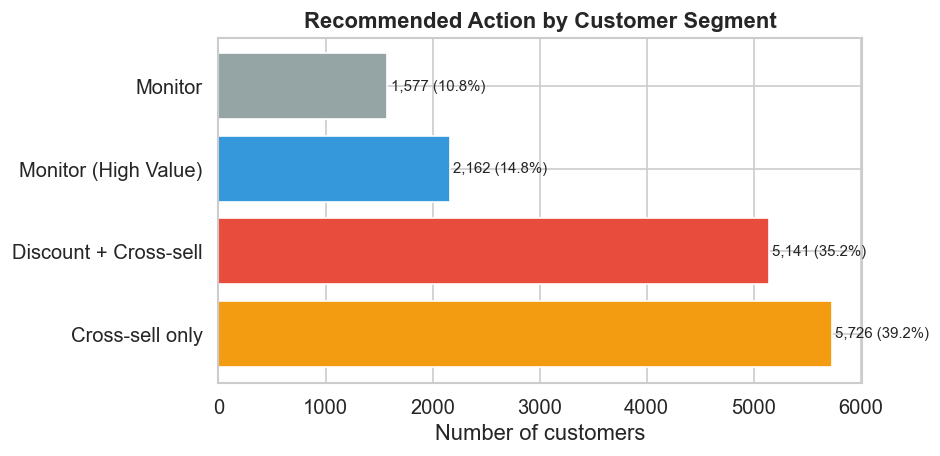

In [6]:
# Final action matrix
median_margin = df['net_margin'].median()

df['action'] = 'Monitor'
df.loc[(df['churn_probability'] >= 0.30) & (df['net_margin'] >= median_margin), 'action'] = 'Discount + Cross-sell'
df.loc[(df['churn_probability'] >= 0.30) & (df['net_margin'] <  median_margin), 'action'] = 'Cross-sell only'
df.loc[(df['churn_probability'] <  0.30) & (df['net_margin'] >= median_margin), 'action'] = 'Monitor (High Value)'

action_summary = df['action'].value_counts().reset_index()
action_summary.columns = ['Action', 'Customers']
action_summary['% of Base'] = (action_summary['Customers'] / len(df) * 100).round(1)
print(action_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'Discount + Cross-sell': '#e74c3c', 'Cross-sell only': '#f39c12',
          'Monitor (High Value)': '#3498db', 'Monitor': '#95a5a6'}
bars = ax.barh(action_summary['Action'], action_summary['Customers'],
                color=[colors[a] for a in action_summary['Action']], edgecolor='white')
for bar, row in zip(bars, action_summary.itertuples()):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{row.Customers:,} ({row._3}%)', va='center', fontsize=9)
ax.set_title('Recommended Action by Customer Segment', fontweight='bold')
ax.set_xlabel('Number of customers')
plt.tight_layout()
plt.savefig(REPORTS_FIG / '19_action_matrix.png', bbox_inches='tight')
plt.show()

## 7. Limitations & Caveats

| Limitation | Implication |
|---|---|
| Historical data only (no competitive pricing) | The model cannot capture whether a competitor offered a lower price — a key driver of price-motivated churn |
| 9.7% class imbalance | Model performance on churners is inherently harder; recall trade-offs required |
| Retention uplift is assumed (30%) | The actual uplift from discounts must be validated via A/B testing |
| Static model | Customer behaviour changes; quarterly retraining is required |
| No CLV data | We optimised for margin, not lifetime value — a CLV-weighted model would be more precise |

---

## 8. Next Steps

| Priority | Action | Owner | Timeline |
|---|---|---|---|
| 1 | A/B test discount programme on a random 50% of high-risk cohort | PowerCo Commercial | 4 weeks |
| 2 | Integrate model into CRM for automated risk scoring | PowerCo IT + BCG X | 6 weeks |
| 3 | Launch gas cross-sell pilot for electricity-only high-risk customers | PowerCo Sales | 6 weeks |
| 4 | Collect competitive pricing data to improve model | PowerCo Commercial | 8 weeks |
| 5 | Implement quarterly model retraining pipeline | BCG X / PowerCo Data | 10 weeks |

---

*This analysis was completed as part of the BCG X Data Science Virtual Experience Programme on Forage.*